In [1]:
#importing the needed libraries
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import seaborn as sns
from scipy.spatial.distance import pdist, squareform

In [2]:
df = pd.read_csv("./dataset/DM1_game_dataset_cleaned.csv")

df.columns

Index(['Name', 'YearPublished', 'GameWeight', 'MinPlayers', 'MaxPlayers',
       'MfgPlaytime', 'MfgAgeRec', 'NumAlternates', 'NumExpansions',
       'NumImplementations', 'IsReimplementation', 'Kickstarted', 'Rating',
       'HasFamily', 'Category', 'Rank', 'EngagementLevel'],
      dtype='object')

## Preprocessing

In [3]:
#checking any missing values
cols = [
    'Name', 'YearPublished', 'GameWeight', 'MinPlayers', 'MaxPlayers',
    'MfgPlaytime', 'MfgAgeRec', 'NumAlternates', 'NumExpansions',
    'NumImplementations', 'IsReimplementation', 'Kickstarted',
    'Rating', 'HasFamily', 'Category', 'Rank', 'EngagementLevel'
]

missing_df = (
    df[cols]
    .isna()
    .sum()
    .to_frame(name='MissingCount')
)

missing_df['MissingPercent'] = (missing_df['MissingCount'] / len(df)) * 100
missing_df = missing_df.sort_values(by='MissingPercent', ascending=False)

print(missing_df)


                    MissingCount  MissingPercent
Name                           0             0.0
NumImplementations             0             0.0
Rank                           0             0.0
Category                       0             0.0
HasFamily                      0             0.0
Rating                         0             0.0
Kickstarted                    0             0.0
IsReimplementation             0             0.0
NumExpansions                  0             0.0
YearPublished                  0             0.0
NumAlternates                  0             0.0
MfgAgeRec                      0             0.0
MfgPlaytime                    0             0.0
MaxPlayers                     0             0.0
MinPlayers                     0             0.0
GameWeight                     0             0.0
EngagementLevel                0             0.0


In [4]:
#looking for outliers and calculating skeweness 
from scipy.stats import skew

numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols

outlier_stats = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outlier_count = outliers.count()
    outlier_pct = (outlier_count / df[col].count()) * 100
    
    outlier_stats.append([col, outlier_count, outlier_pct, IQR, lower_bound, upper_bound])

outliers_df = pd.DataFrame(outlier_stats, columns=[
    'Variable', 'OutlierCount', 'OutlierPercent', 'IQR', 'LowerBound', 'UpperBound'
]).sort_values(by='OutlierPercent', ascending=False)

print(outliers_df)

skewness_values = []

for col in numeric_cols:
    sk = skew(df[col].dropna())
    skewness_values.append([col, sk])

skew_df = pd.DataFrame(skewness_values, columns=['Variable', 'Skewness'])\
          .sort_values(by='Skewness', ascending=False)

print(skew_df)


              Variable  OutlierCount  OutlierPercent           IQR  \
2           MinPlayers          6848       31.299420      0.000000   
8   NumImplementations          4829       22.071393      0.000000   
10         Kickstarted          3339       15.261209      0.000000   
9   IsReimplementation          2530       11.563600      0.000000   
6        NumAlternates          1899        8.679556      0.693147   
4          MfgPlaytime          1449        6.622789     60.000000   
7        NumExpansions          1293        5.909776      0.693147   
3           MaxPlayers          1155        5.279035      2.000000   
0        YearPublished          1141        5.215046     16.000000   
13     EngagementLevel           451        2.061337      1.900240   
1           GameWeight           150        0.685589      1.168000   
5            MfgAgeRec            14        0.063988      4.000000   
11           HasFamily             0        0.000000      1.000000   
12                Ra

In [5]:
#handling outliers with log transformations
log_transform_cols = [
    "MinPlayers",
    "NumImplementations",
    "NumAlternates",
    "NumExpansions",
    "MfgPlaytime",
    "MaxPlayers"
]

for col in log_transform_cols:
    df[col] = np.log1p(df[col])


In [6]:
#standardization
numeric_vars = [
    "GameWeight",
    "MinPlayers",        
    "MaxPlayers",        
    "MfgPlaytime",       
    "MfgAgeRec",
    "NumAlternates",     
    "NumExpansions",     
    "NumImplementations",
    "EngagementLevel"
]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_numeric = scaler.fit_transform(df[numeric_vars])

scaled_numeric = pd.DataFrame(scaled_numeric, columns=numeric_vars, index=df.index)

binary_vars = [
    "IsReimplementation",
    "Kickstarted",
    "HasFamily"
]

#recombinig together the variables
df_cluster = pd.concat([scaled_numeric, df[binary_vars]], axis=1)



In [7]:
#checking correlations

# correlation matrix
corr = df_cluster.corr()

corr_pairs = corr.unstack().reset_index()
corr_pairs.columns = ["var1", "var2", "corr"]

corr_pairs = corr_pairs[corr_pairs["var1"] < corr_pairs["var2"]]

#filtering meaningful correlations
significant_corr = corr_pairs[abs(corr_pairs["corr"]) > 0.3]\
                       .sort_values(by="corr", ascending=False)

significant_corr

#I would keep NumImplementations and IsReimplementation even if they are correlated, they are not redundant even if correlated
#same reasoning with GameWeight and MfgPlaytime


,var1,var2,corr
3,GameWeight,MfgPlaytime,0.695419
115,IsReimplementation,NumImplementations,0.653045
4,GameWeight,MfgAgeRec,0.482298
51,MfgAgeRec,MfgPlaytime,0.482251
102,EngagementLevel,NumExpansions,0.418888
101,EngagementLevel,NumAlternates,0.386237


## Ward Linkage Method

In [13]:
Z = linkage(df_cluster, method='ward')


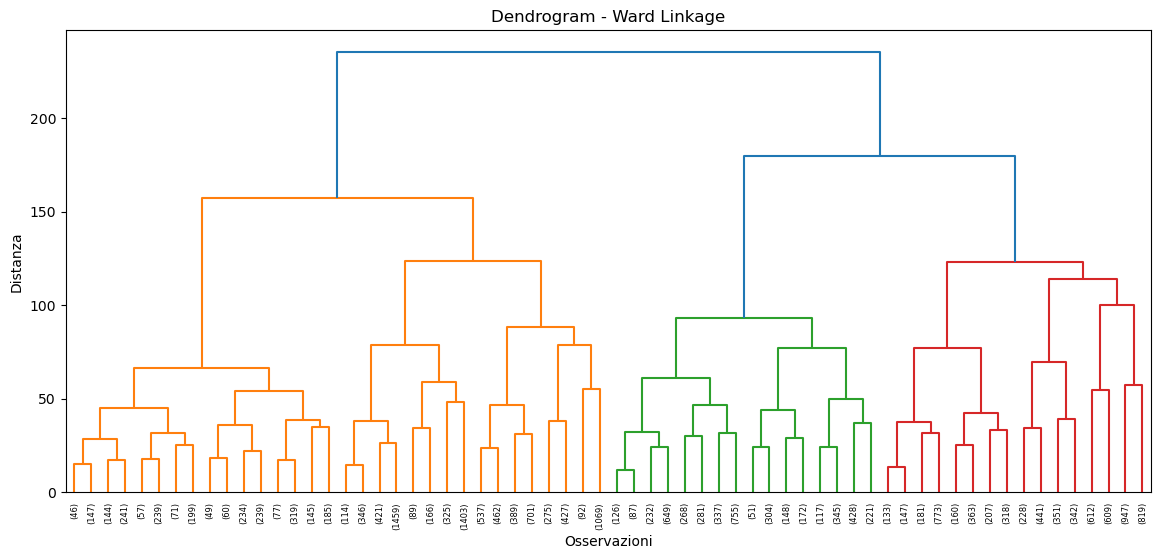

In [24]:
plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode='level', p=5)  # p=5 per rendere leggibile
plt.title("Dendrogram - Ward Linkage")
plt.xlabel("Osservazioni")
plt.ylabel("Distanza")
plt.show()


{'icoord': [[35.0, 35.0, 45.0, 45.0],
  [25.0, 25.0, 40.0, 40.0],
  [15.0, 15.0, 32.5, 32.5],
  [5.0, 5.0, 23.75, 23.75],
  [55.0, 55.0, 65.0, 65.0],
  [75.0, 75.0, 85.0, 85.0],
  [60.0, 60.0, 80.0, 80.0],
  [105.0, 105.0, 115.0, 115.0],
  [95.0, 95.0, 110.0, 110.0],
  [70.0, 70.0, 102.5, 102.5],
  [14.375, 14.375, 86.25, 86.25],
  [125.0, 125.0, 135.0, 135.0],
  [155.0, 155.0, 165.0, 165.0],
  [175.0, 175.0, 185.0, 185.0],
  [195.0, 195.0, 205.0, 205.0],
  [180.0, 180.0, 200.0, 200.0],
  [160.0, 160.0, 190.0, 190.0],
  [145.0, 145.0, 175.0, 175.0],
  [130.0, 130.0, 160.0, 160.0],
  [225.0, 225.0, 235.0, 235.0],
  [215.0, 215.0, 230.0, 230.0],
  [255.0, 255.0, 265.0, 265.0],
  [245.0, 245.0, 260.0, 260.0],
  [222.5, 222.5, 252.5, 252.5],
  [275.0, 275.0, 285.0, 285.0],
  [305.0, 305.0, 315.0, 315.0],
  [295.0, 295.0, 310.0, 310.0],
  [280.0, 280.0, 302.5, 302.5],
  [237.5, 237.5, 291.25, 291.25],
  [145.0, 145.0, 264.375, 264.375],
  [325.0, 325.0, 335.0, 335.0],
  [355.0, 355.0, 365.0

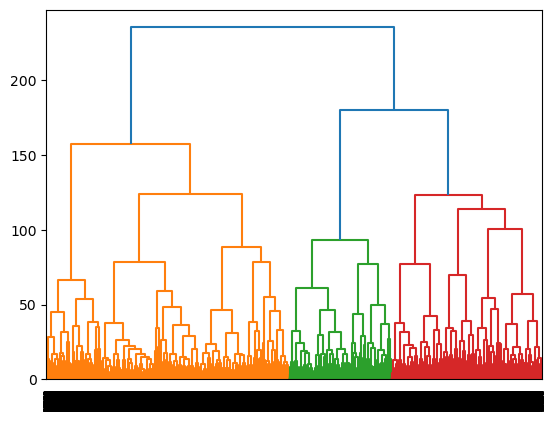

In [21]:
dendrogram(Z)


In [26]:
#silhouette coefficient
from sklearn.metrics import silhouette_score

sil_scores = {}

for k in range(2, 11):
    clusters_k = fcluster(Z, t=k, criterion='maxclust')
    score = silhouette_score(df_cluster, clusters_k)
    sil_scores[k] = score

sil_scores

{2: np.float64(0.17987383135428112),
 3: np.float64(0.15867929350234716),
 4: np.float64(0.15633864822027735),
 5: np.float64(0.1221562927858548),
 6: np.float64(0.12947706678669077),
 7: np.float64(0.1412475755739617),
 8: np.float64(0.1475415359707905),
 9: np.float64(0.13798383902697547),
 10: np.float64(0.13285736713381446)}

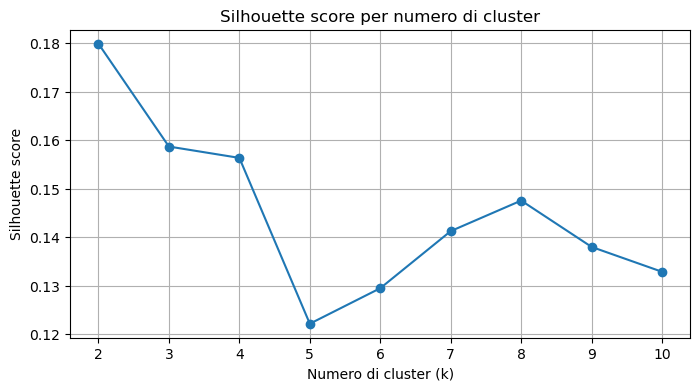

In [27]:
#silhouette graph
plt.figure(figsize=(8, 4))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker='o')
plt.title("Silhouette score per numero di cluster")
plt.xlabel("Numero di cluster (k)")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()


In [14]:
clusters = fcluster(Z, t=180, criterion='distance')
df_cluster["cluster"] = clusters
df["cluster"] = clusters

In [15]:
#retrying just with numeric variables since nonary variables can disturb the cluster structure (they create quick jumps)
df_cluster_num = df_cluster[numeric_vars]


In [16]:
Z_num = linkage(df_cluster_num, method='ward')


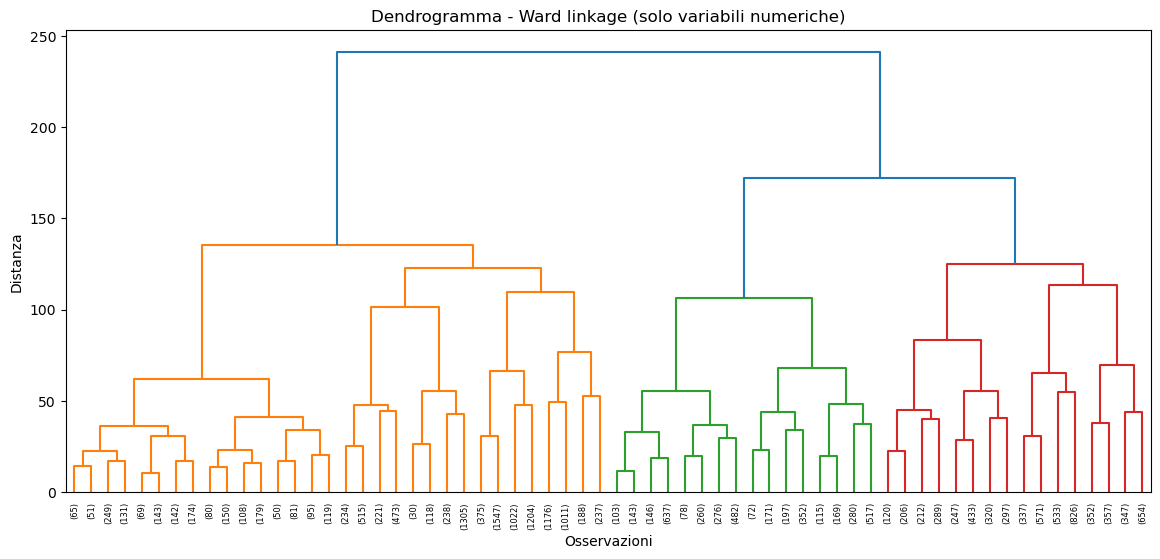

In [30]:


plt.figure(figsize=(14, 6))
dendrogram(Z_num, truncate_mode='level', p=5)
plt.title("Dendrogramma - Ward linkage (solo variabili numeriche)")
plt.xlabel("Osservazioni")
plt.ylabel("Distanza")
plt.show()

In [31]:

sil_scores_num = {}

for k in range(2, 11):
    clusters_k = fcluster(Z_num, t=k, criterion='maxclust')
    score = silhouette_score(df_cluster_num, clusters_k)
    sil_scores_num[k] = score

sil_scores_num


{2: np.float64(0.15148205152648564),
 3: np.float64(0.1329897756449127),
 4: np.float64(0.11637996406432963),
 5: np.float64(0.12697498796323384),
 6: np.float64(0.10900195948209486),
 7: np.float64(0.1202881370421123),
 8: np.float64(0.11744516074704678),
 9: np.float64(0.11598917309120262),
 10: np.float64(0.12353841152034843)}

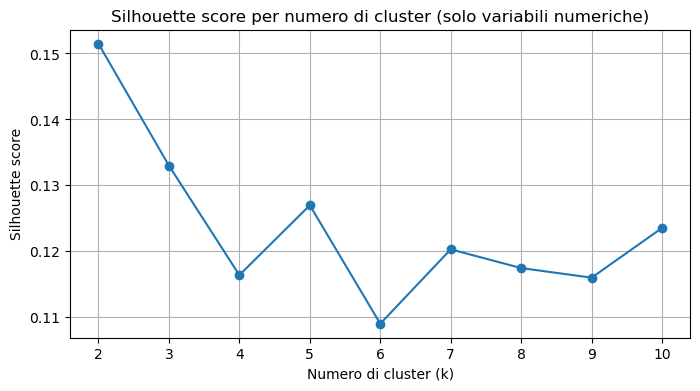

In [32]:
plt.figure(figsize=(8, 4))
plt.plot(list(sil_scores_num.keys()), list(sil_scores_num.values()), marker='o')
plt.title("Silhouette score per numero di cluster (solo variabili numeriche)")
plt.xlabel("Numero di cluster (k)")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()


## Average Linkage Method

In [33]:
Z_avg = linkage(df_cluster, method='average')


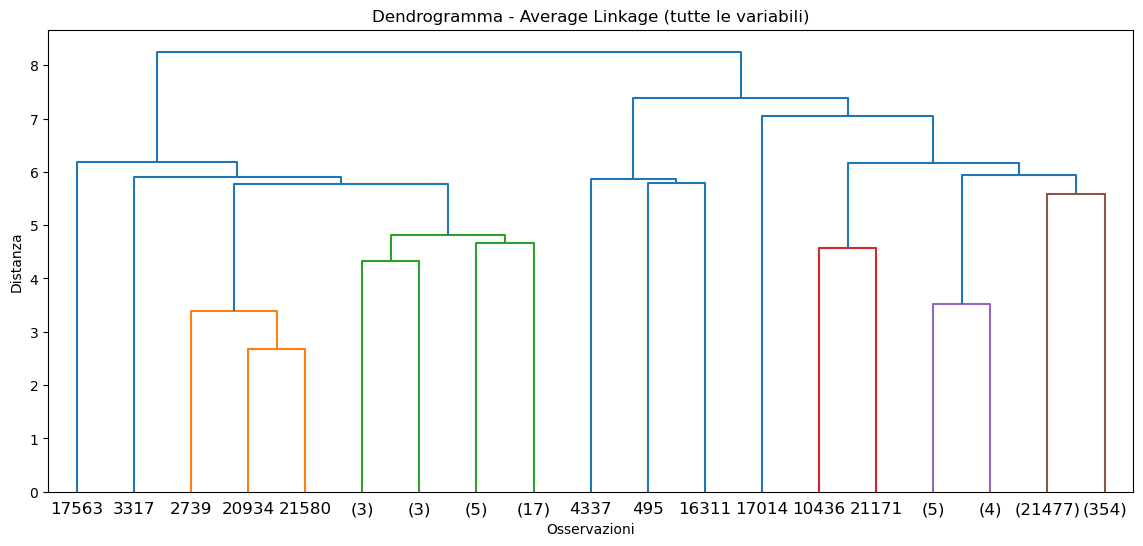

In [34]:


plt.figure(figsize=(14, 6))
dendrogram(Z_avg, truncate_mode='level', p=5)
plt.title("Dendrogramma - Average Linkage (tutte le variabili)")
plt.xlabel("Osservazioni")
plt.ylabel("Distanza")
plt.show()


In [35]:


sil_scores_avg = {}

for k in range(2, 11):
    clusters_k = fcluster(Z_avg, t=k, criterion='maxclust')
    score = silhouette_score(df_cluster, clusters_k)
    sil_scores_avg[k] = score

sil_scores_avg


{2: np.float64(0.47063025335163794),
 3: np.float64(0.3694597731296684),
 4: np.float64(0.3226903194623242),
 5: np.float64(0.3216147301100306),
 6: np.float64(0.2284071529038055),
 7: np.float64(0.18486871902290478),
 8: np.float64(0.18450133684089576),
 9: np.float64(0.18180351065803804),
 10: np.float64(0.1741515419294394)}

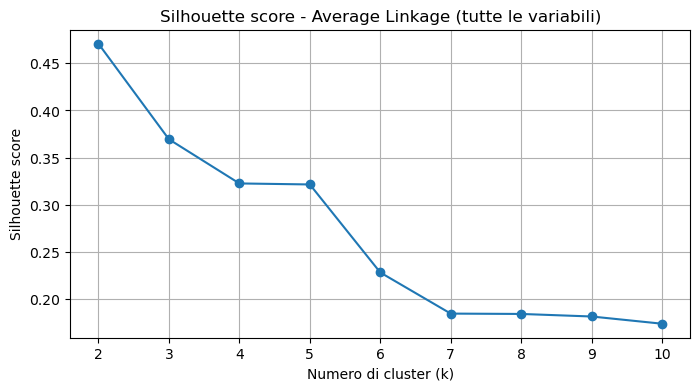

In [36]:
plt.figure(figsize=(8, 4))
plt.plot(list(sil_scores_avg.keys()), list(sil_scores_avg.values()), marker='o')
plt.title("Silhouette score - Average Linkage (tutte le variabili)")
plt.xlabel("Numero di cluster (k)")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()


In [37]:
#assigning clusters, we choose number of clusters = 3
k_opt = 3  # we can also put 2
clusters = fcluster(Z_avg, t=k_opt, criterion='maxclust')

df_cluster["cluster_avg"] = clusters
df["cluster_avg"] = clusters


In [38]:
df.groupby("cluster_avg")[numeric_vars + binary_vars].mean()


,GameWeight,MinPlayers,MaxPlayers,MfgPlaytime,MfgAgeRec,NumAlternates,NumExpansions,NumImplementations,EngagementLevel,IsReimplementation,Kickstarted,HasFamily
cluster_avg,,,,,,,,,,,,
1,1.382721,0.569472,0.727491,0.455547,9.000000,0.238169,0.026884,0.120306,4.377604,0.151515,0.121212,0.181818
2,4.782233,0.626800,0.851523,1.169631,14.000000,0.117598,0.383249,0.264674,5.126151,0.333333,0.333333,0.333333
3,2.018141,0.543759,0.676796,0.944680,10.214623,0.179200,0.113028,0.082924,4.791125,0.115552,0.152635,0.302843


In [41]:
#THIS IS SO BAD!
df["cluster_avg"].value_counts()


cluster_avg
3    21843
1       33
2        3
Name: count, dtype: int64

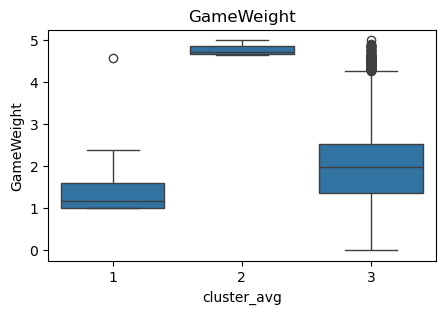

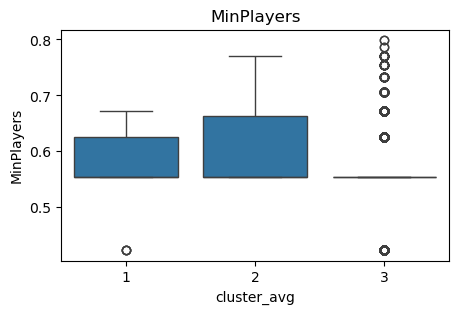

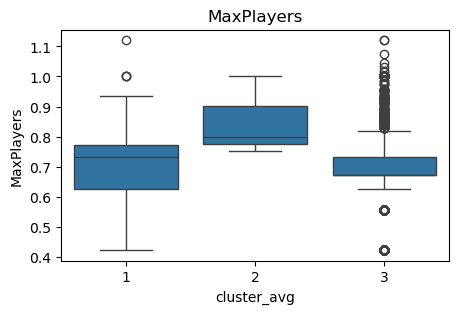

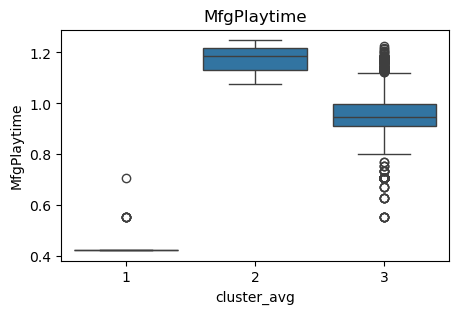

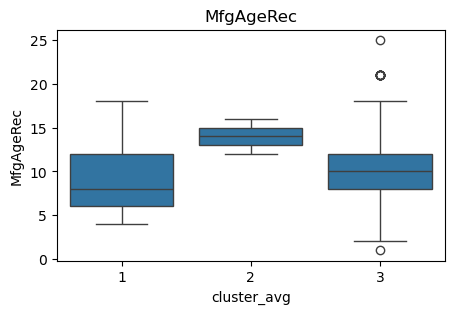

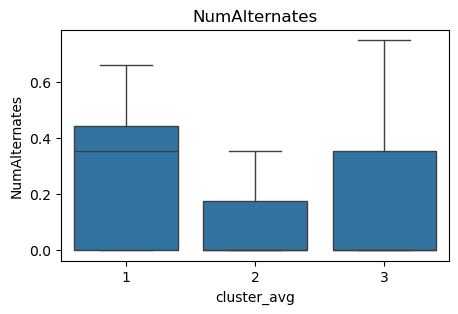

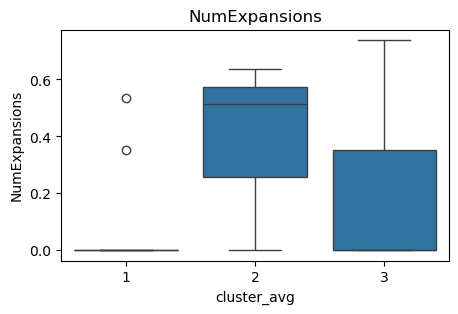

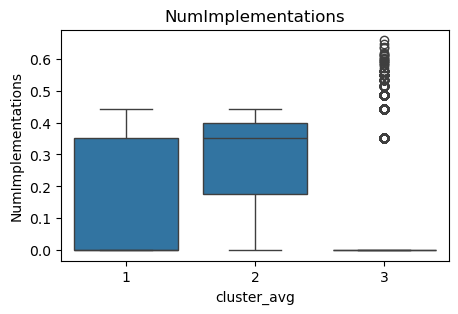

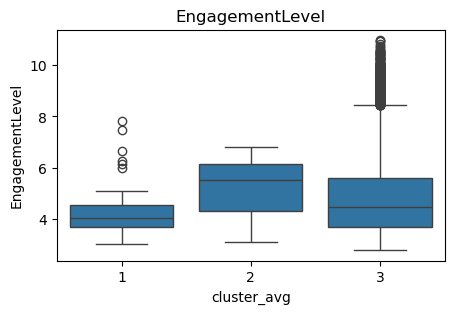

In [40]:

for col in numeric_vars:
    plt.figure(figsize=(5,3))
    sns.boxplot(x="cluster_avg", y=col, data=df)
    plt.title(col)
    plt.show()


## Complete Linkage

In [8]:

Z_comp = linkage(df_cluster, method='complete')


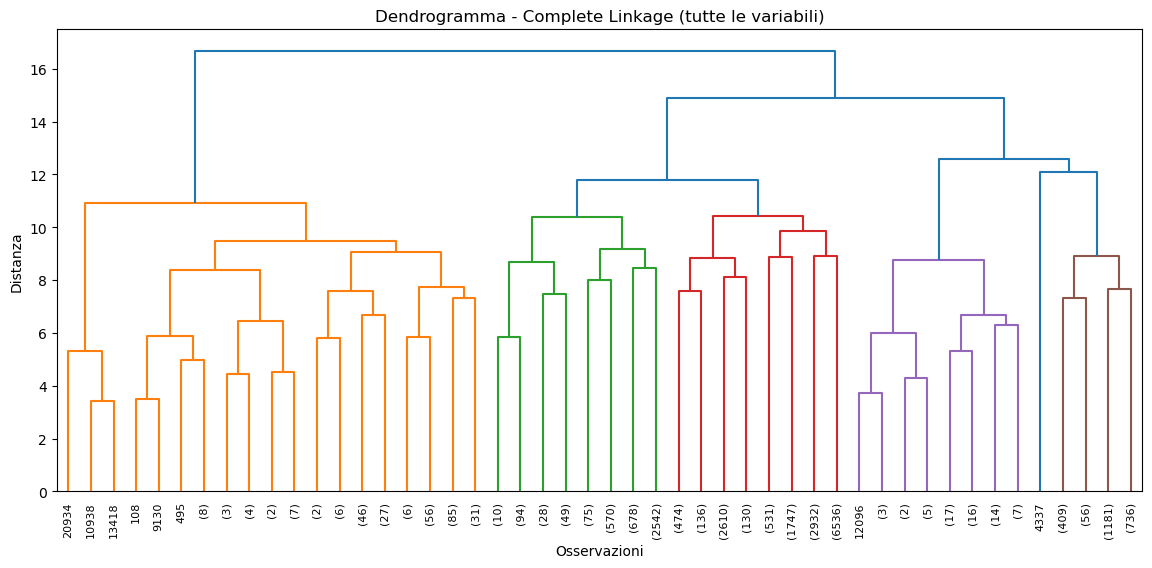

In [9]:

plt.figure(figsize=(14, 6))
dendrogram(Z_comp, truncate_mode='level', p=5)
plt.title("Dendrogramma - Complete Linkage (tutte le variabili)")
plt.xlabel("Osservazioni")
plt.ylabel("Distanza")
plt.show()


In [20]:
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import fcluster

sil_scores_comp = {}

for k in range(2, 11):
    clusters_k = fcluster(Z_comp, t=k, criterion='maxclust')
    score = silhouette_score(df_cluster, clusters_k)
    sil_scores_comp[k] = score

sil_scores_comp


{2: np.float64(0.3691491518276166),
 3: np.float64(0.12946619429617898),
 4: np.float64(0.11838725861042955),
 5: np.float64(0.11789286063164803),
 6: np.float64(0.13315649142487654),
 7: np.float64(0.13278434212698445),
 8: np.float64(0.05984924256770368),
 9: np.float64(0.05529887844862978),
 10: np.float64(0.07638868026335517)}

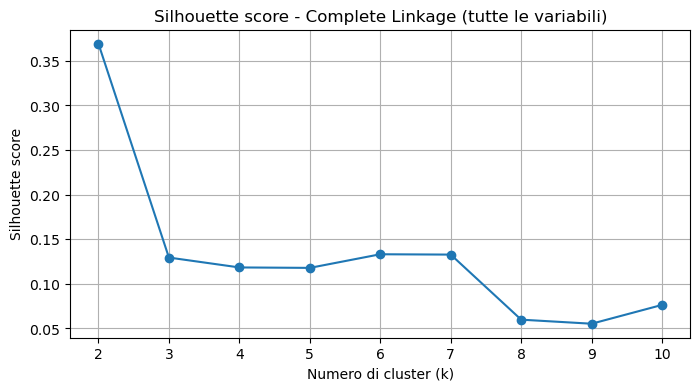

In [21]:
plt.figure(figsize=(8, 4))
plt.plot(list(sil_scores_comp.keys()), list(sil_scores_comp.values()), marker='o')
plt.title("Silhouette score - Complete Linkage (tutte le variabili)")
plt.xlabel("Numero di cluster (k)")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()


In [22]:
#clusters assignation
clusters_2 = fcluster(Z_comp, t=2, criterion='maxclust')
df_cluster["cluster_comp_2"] = clusters_2
df["cluster_comp_2"] = clusters_2

In [24]:
df["cluster_comp_2"].value_counts()
#THIS IS STILL SOOO BAD! THESE ARE NOT CLUSTERS, BLOCK OF POINTS AND OUTLIERS...

cluster_comp_2
2    21590
1      289
Name: count, dtype: int64

In [25]:
#reasoning with only numerical columns
Z_num2 = linkage(df_cluster_num, method='complete')


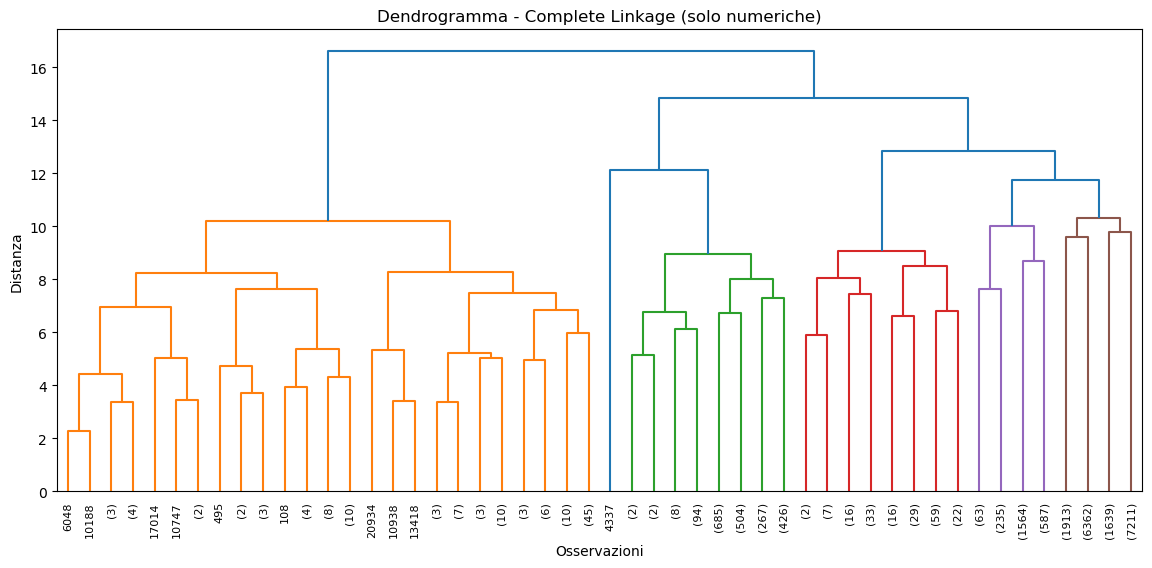

In [18]:

plt.figure(figsize=(14, 6))
dendrogram(Z_num2, truncate_mode='level', p=5)
plt.title("Dendrogramma - Complete Linkage (solo numeriche)")
plt.xlabel("Osservazioni")
plt.ylabel("Distanza")
plt.show()


In [26]:
from sklearn.metrics import silhouette_score

sil_scores_comp_num = {}

for k in range(2, 11):
    clusters_k = fcluster(Z_num2, t=k, criterion='maxclust')
    score = silhouette_score(df_cluster_num, clusters_k)
    sil_scores_comp_num[k] = score

sil_scores_comp_num


{2: np.float64(0.46037154191568114),
 3: np.float64(0.15942198607734748),
 4: np.float64(0.1593539572416769),
 5: np.float64(0.15879725453786334),
 6: np.float64(0.11978962655865237),
 7: np.float64(0.07080525010832059),
 8: np.float64(0.06976726901559122),
 9: np.float64(0.06601927048862462),
 10: np.float64(0.050225270935058894)}

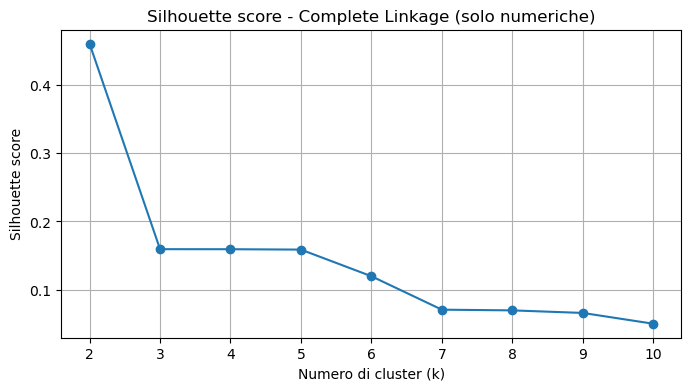

In [27]:
plt.figure(figsize=(8, 4))
plt.plot(list(sil_scores_comp_num.keys()), list(sil_scores_comp_num.values()), marker='o')
plt.title("Silhouette score - Complete Linkage (solo numeriche)")
plt.xlabel("Numero di cluster (k)")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()


In [29]:
clusters_k2 = fcluster(Z_num2, t=2, criterion='maxclust')
pd.Series(clusters_k2).value_counts()
#THIS IS SOOOOO BAD STILL

2    21747
1      132
Name: count, dtype: int64

## Single Linkage

In [32]:
#considering first only numerical
Z_single = linkage(df_cluster_num, method='single')


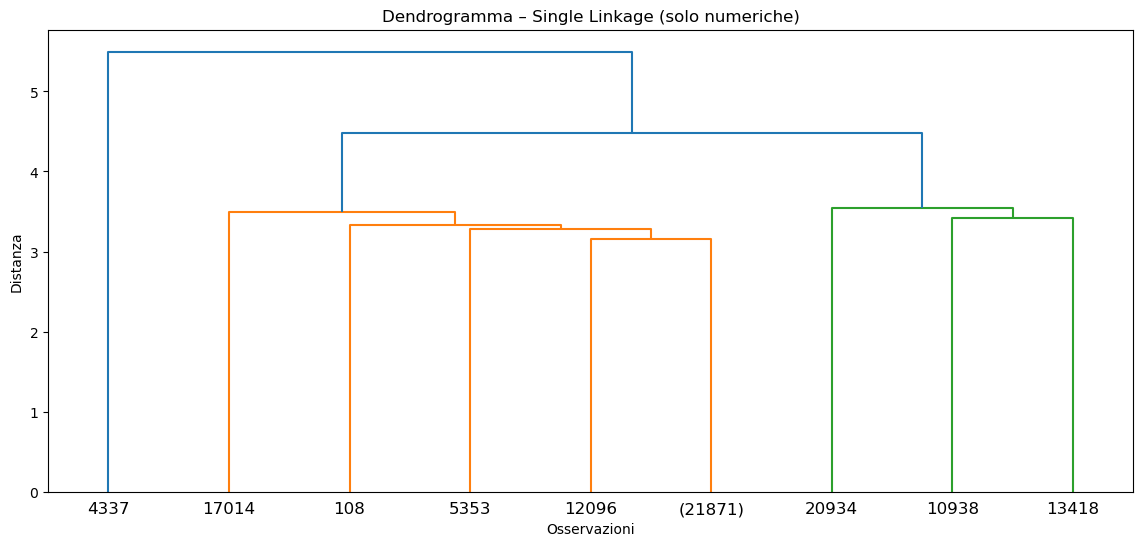

In [31]:
plt.figure(figsize=(14, 6))
dendrogram(Z_single, truncate_mode='level', p=5)
plt.title("Dendrogramma – Single Linkage (solo numeriche)")
plt.xlabel("Osservazioni")
plt.ylabel("Distanza")
plt.show()

In [33]:
from sklearn.metrics import silhouette_score

sil_scores_single = {}

for k in range(2, 11):
    clusters_k = fcluster(Z_single, t=k, criterion='maxclust')
    score = silhouette_score(df_cluster_num, clusters_k)
    sil_scores_single[k] = score

sil_scores_single


{2: np.float64(0.6224203927992886),
 3: np.float64(0.6090483130880116),
 4: np.float64(0.606018712642471),
 5: np.float64(0.5092562364674218),
 6: np.float64(0.5090844583542244),
 7: np.float64(0.5072333892716797),
 8: np.float64(0.32168848411620393),
 9: np.float64(0.31948342302028504),
 10: np.float64(0.3193027105569704)}

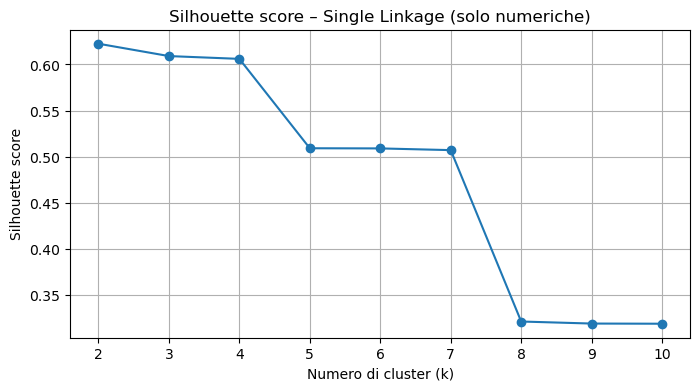

In [34]:
plt.figure(figsize=(8, 4))
plt.plot(list(sil_scores_single.keys()), list(sil_scores_single.values()), marker='o')
plt.title("Silhouette score – Single Linkage (solo numeriche)")
plt.xlabel("Numero di cluster (k)")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()


In [35]:
clusters_single_2 = fcluster(Z_single, t=2, criterion='maxclust')
clusters_single_3 = fcluster(Z_single, t=3, criterion='maxclust')


In [37]:
print("Value counts k=2:")
print(pd.Series(clusters_single_2).value_counts())

print("\nValue counts k=3:")
print(pd.Series(clusters_single_3).value_counts())
#THIS IS SUUUUUOPER BAD.....USELESS!!!!!!!!


Value counts k=2:
1    21878
2        1
Name: count, dtype: int64

Value counts k=3:
1    21875
2        3
3        1
Name: count, dtype: int64


## Centroid Distance

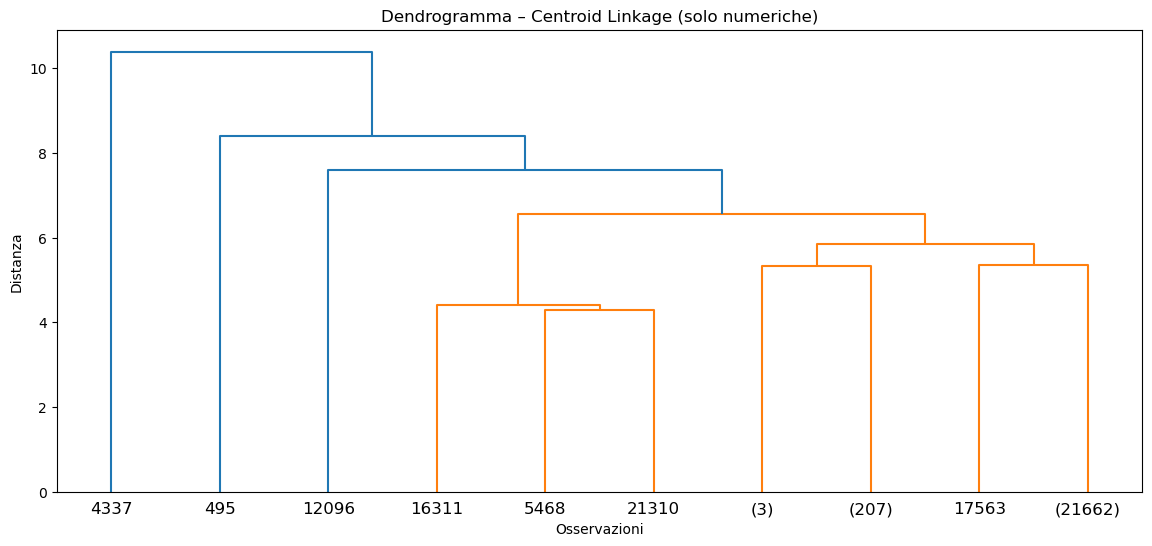

In [49]:
Z_centroid = linkage(df_cluster_num, method='centroid')

plt.figure(figsize=(14, 6))
dendrogram(Z_centroid, truncate_mode='level', p=5)
plt.title("Dendrogramma – Centroid Linkage (solo numeriche)")
plt.xlabel("Osservazioni")
plt.ylabel("Distanza")
plt.show()

In [50]:
sil_scores_centroid = {}
for k in range(2, 11):
    clusters_k = fcluster(Z_centroid, t=k, criterion='maxclust')
    sil_scores_centroid[k] = silhouette_score(df_cluster_num, clusters_k)

sil_scores_centroid

{2: np.float64(0.6224203927992886),
 3: np.float64(0.5405074133350862),
 4: np.float64(0.47771393016625624),
 5: np.float64(0.41874093364422216),
 6: np.float64(0.39027976159383326),
 7: np.float64(0.30745900578765667),
 8: np.float64(0.3063961540617095),
 9: np.float64(0.2937836113101037),
 10: np.float64(0.2740124846424836)}

In [51]:
pd.Series(fcluster(Z_centroid, t=2, criterion='maxclust')).value_counts()
pd.Series(fcluster(Z_centroid, t=3, criterion='maxclust')).value_counts()

1    21877
2        1
3        1
Name: count, dtype: int64

## Let's try to change the kind of distance used --> Manhattan Distance

In [40]:
from scipy.spatial.distance import pdist



In [41]:
#still working only with numerical variables
D_manh = pdist(df_cluster_num, metric='cityblock')


In [42]:
#complete linkage with Manhattan Distance
Z_manh_complete = linkage(D_manh, method='complete')


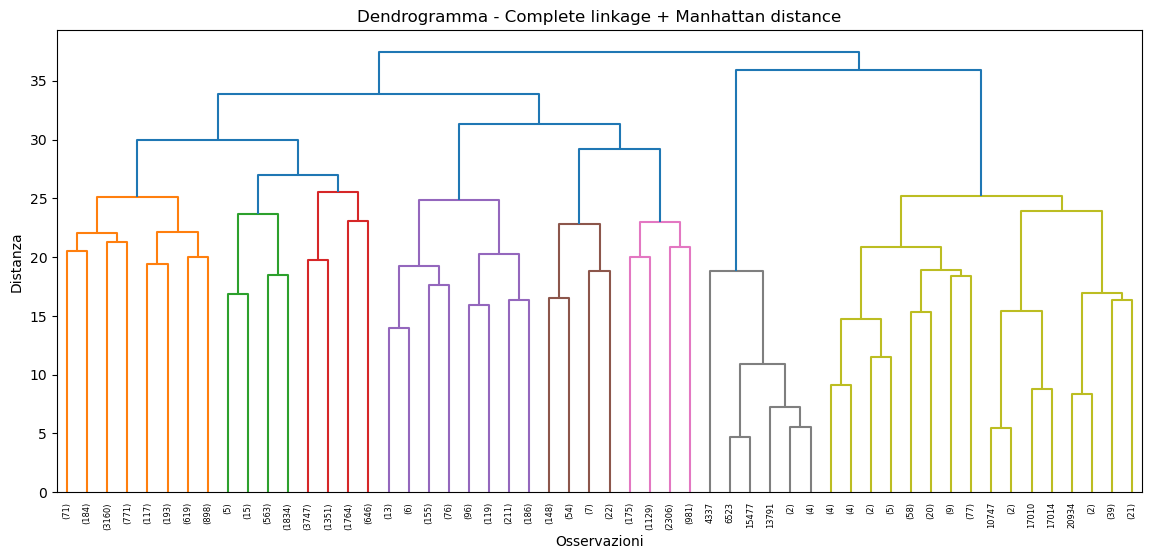

In [43]:
plt.figure(figsize=(14,6))
dendrogram(Z_manh_complete, truncate_mode='level', p=5)
plt.title("Dendrogramma - Complete linkage + Manhattan distance")
plt.xlabel("Osservazioni")
plt.ylabel("Distanza")
plt.show()


In [44]:
from sklearn.metrics import silhouette_score

sil_scores_manh = {}

for k in range(2, 11):
    clusters_k = fcluster(Z_manh_complete, t=k, criterion='maxclust')
    score = silhouette_score(df_cluster_num, clusters_k)
    sil_scores_manh[k] = score

sil_scores_manh


{2: np.float64(0.39957272596302484),
 3: np.float64(0.3178351681985586),
 4: np.float64(0.12561486861576746),
 5: np.float64(0.10880246166519204),
 6: np.float64(0.0858752531725077),
 7: np.float64(0.07903011740069028),
 8: np.float64(0.048260197625644645),
 9: np.float64(0.044891981681913516),
 10: np.float64(0.04330647050376709)}

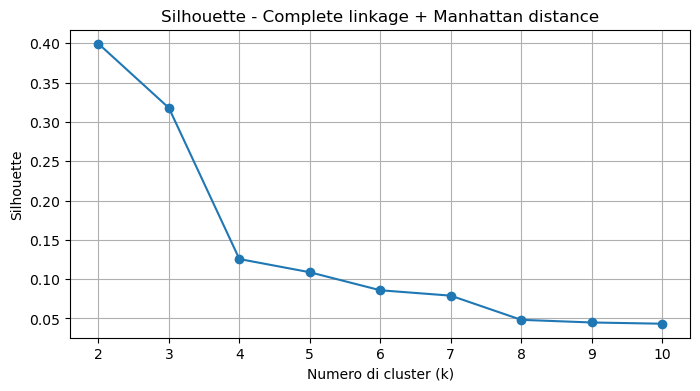

In [45]:
plt.figure(figsize=(8,4))
plt.plot(list(sil_scores_manh.keys()), list(sil_scores_manh.values()), marker='o')
plt.title("Silhouette - Complete linkage + Manhattan distance")
plt.xlabel("Numero di cluster (k)")
plt.ylabel("Silhouette")
plt.grid(True)
plt.show()

In [ ]:
clusters_manh_2 = fcluster(Z_manh_complete, t=2, criterion='maxclust')
pd.Series(clusters_manh_2).value_counts()
#SUPER BAD


1    21622
2      257
Name: count, dtype: int64

In [48]:
clusters_manh_3 = fcluster(Z_manh_complete, t=3, criterion='maxclust')
pd.Series(clusters_manh_3).value_counts()
#SUPER BAD


1    21622
3      247
2       10
Name: count, dtype: int64